--- Створено матриці даних ---
X:
 [[ 89  93  83]
 [100  86  78]
 [ 97  90  88]
 [ 83  99 100]
 [100  81  75]]
y:
 [88 86 91 96 83]
------------------------------

[Завдання 1] Ваги OLS (аналітичний розв'язок):
Вага для Grade 1: 0.2308
Вага для Grade 2: 0.3391
Вага для Grade 3: 0.4327
------------------------------

[Завдання 2] Запуск градієнтного спуску (2000 ітерацій)...


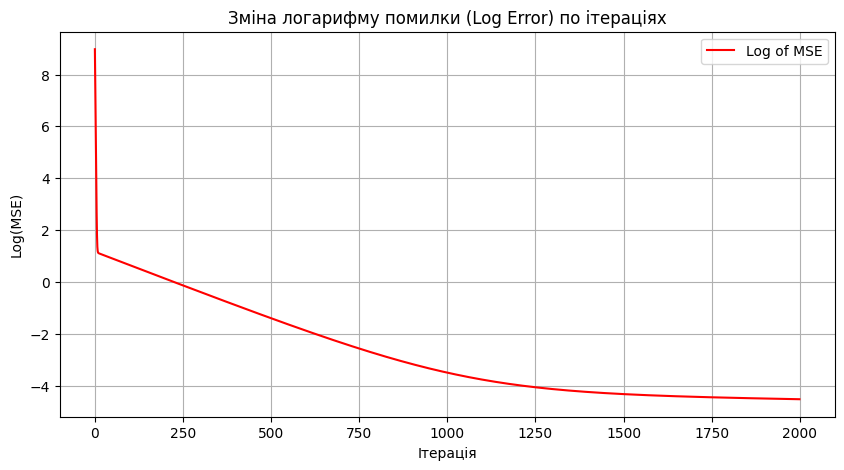


Результати градієнтного спуску після фіксованих ітерацій:
Вага для Grade 1: 0.2253
Вага для Grade 2: 0.3723
Вага для Grade 3: 0.4037
------------------------------

[Завдання 2.e] Запуск до збіжності (якщо зміна ваг < 1e-06)...
Алгоритм збігся на ітерації № 16503!

Ваги отримані після повної збіжності:
Вага для Grade 1: 0.2296
Вага для Grade 2: 0.3461
Вага для Grade 3: 0.4268
------------------------------

ВИСНОВОК:

1. Аналітичний метод OLS (Крок 1) дає точний математичний результат миттєво, використовуючи лише матричні операції.
2. Градієнтний спуск (Крок 2) дуже сильно залежить від розміру кроку (learning rate):
   - Якщо step size занадто великий (наприклад, 0.01), помилка йде в нескінченність (Exploding Gradient).
   - Якщо step size занадто малий (наприклад, 1e-6), алгоритму потрібно дуже багато ітерацій для досягнення точності OLS.
3. Графік логарифму помилки наочно показує, як MSE стрімко падає на перших ітераціях, а потім плавно стабілізується (виходить на плато).



In [1]:
import matplotlib.pyplot as plt
import numpy as np


X = np.array(
    [
        [89, 93, 83],
        [100, 86, 78],
        [97, 90, 88],
        [83, 99, 100],
        [100, 81, 75],
    ]
)

y = np.array([88, 86, 91, 96, 83])

print("--- Створено матриці даних ---")
print("X:\n", X)
print("y:\n", y)
print("-" * 30)


X_transpose = X.T
X_transpose_dot_X = X_transpose @ X
inverse_X_dot_X = np.linalg.inv(X_transpose_dot_X)

interim_matrix = inverse_X_dot_X @ X_transpose
weights_ols = interim_matrix @ y

print("\n[Завдання 1] Ваги OLS (аналітичний розв'язок):")
print(f"Вага для Grade 1: {weights_ols[0]:.4f}")
print(f"Вага для Grade 2: {weights_ols[1]:.4f}")
print(f"Вага для Grade 3: {weights_ols[2]:.4f}")
print("-" * 30)


learning_rate = 0.00001
iterations = 2000

weights_gd = np.zeros(X.shape[1])
errors_history = []

print(f"\n[Завдання 2] Запуск градієнтного спуску ({iterations} ітерацій)...")

for i in range(iterations):
    y_pred = X @ weights_gd
    error_vector = y_pred - y
    mse = np.mean(error_vector**2)
    errors_history.append(mse)

    gradient = (2 / len(y)) * (X.T @ error_vector)

    weights_gd = weights_gd - learning_rate * gradient

plt.figure(figsize=(10, 5))
plt.plot(np.log(errors_history), color="red", label="Log of MSE")
plt.title("Зміна логарифму помилки (Log Error) по ітераціях")
plt.xlabel("Ітерація")
plt.ylabel("Log(MSE)")
plt.grid(True)
plt.legend()
plt.show()

print("\nРезультати градієнтного спуску після фіксованих ітерацій:")
print(f"Вага для Grade 1: {weights_gd[0]:.4f}")
print(f"Вага для Grade 2: {weights_gd[1]:.4f}")
print(f"Вага для Grade 3: {weights_gd[2]:.4f}")
print("-" * 30)


weights_conv = np.zeros(X.shape[1]) 
tolerance = 0.000001 
max_steps = 100000  

print(
    f"\n[Завдання 2.e] Запуск до збіжності (якщо зміна ваг < {tolerance})..."
)

for step in range(max_steps):
    y_pred = X @ weights_conv
    error_vector = y_pred - y
    gradient = (2 / len(y)) * (X.T @ error_vector)

    old_weights = weights_conv.copy()
    weights_conv = weights_conv - learning_rate * gradient
    weight_change = np.linalg.norm(weights_conv - old_weights)

    if weight_change < tolerance:
        print(f"Алгоритм збігся на ітерації № {step}!")
        break

print("\nВаги отримані після повної збіжності:")
print(f"Вага для Grade 1: {weights_conv[0]:.4f}")
print(f"Вага для Grade 2: {weights_conv[1]:.4f}")
print(f"Вага для Grade 3: {weights_conv[2]:.4f}")
print("-" * 30)

print("\nВИСНОВОК:")
summary = """
1. Аналітичний метод OLS (Крок 1) дає точний математичний результат миттєво, використовуючи лише матричні операції.
2. Градієнтний спуск (Крок 2) дуже сильно залежить від розміру кроку (learning rate):
   - Якщо step size занадто великий (наприклад, 0.01), помилка йде в нескінченність (Exploding Gradient).
   - Якщо step size занадто малий (наприклад, 1e-6), алгоритму потрібно дуже багато ітерацій для досягнення точності OLS.
3. Графік логарифму помилки наочно показує, як MSE стрімко падає на перших ітераціях, а потім плавно стабілізується (виходить на плато).
"""
print(summary)